### Sample causal-set probabilities for weight distributions
This uses the Monte Carlo approach from the paper.

In [1]:
from snnpiece.analysis.causal_weights import sampleWeightsForCausalPieces

normal_low_mean_wide_sigma, _ = sampleWeightsForCausalPieces('normal', [0.8/100, 4/100], 1e4, 100, 1424242)
normal_high_mean_wide_sigma, _ = sampleWeightsForCausalPieces('normal', [3/100, 4/100], 1e4, 100, 1427842)

normal_mid_mean_wide_sigma, _ = sampleWeightsForCausalPieces('normal', [2/100, 6/100], 1e4, 100, 1424)
normal_mid_mean_narrow_sigma, _ = sampleWeightsForCausalPieces('normal', [2/100, 1/100], 1e4, 100, 5142442)

shifted_uniform_fit, _ = sampleWeightsForCausalPieces('shifted_uniform', (1.016*100**(-0.54), 1.8488*100**(-0.389)), 1e4, 100, 424242)
normal_fit, _ = sampleWeightsForCausalPieces('normal', (1.69*100**(-0.7856), 1.132*100**(-0.487)), 1e4, 100, 424242)

Plot probability distributions

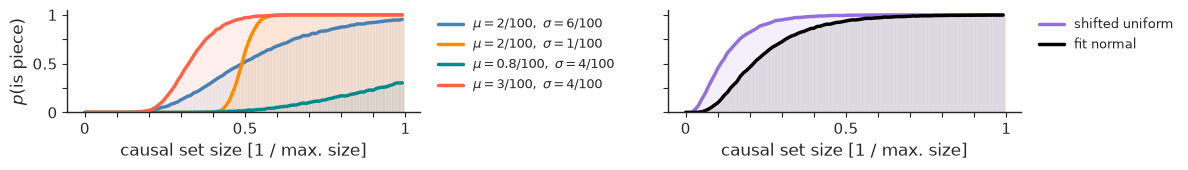

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'mathtext.fontset': 'dejavusans',
    'axes.linewidth': 1.0,
})

curves = [
    (normal_mid_mean_wide_sigma, r'$\mu=2/100,\ \sigma=6/100$', 'steelblue'),
    (normal_mid_mean_narrow_sigma, r'$\mu=2/100,\ \sigma=1/100$', 'darkorange'),
    (normal_low_mean_wide_sigma, r'$\mu=0.8/100,\ \sigma=4/100$', 'darkcyan'),
    (normal_high_mean_wide_sigma, r'$\mu=3/100,\ \sigma=4/100$', 'tomato'),
    (shifted_uniform_fit, 'shifted uniform', 'mediumpurple'),
    (normal_fit, 'fit normal', 'black'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 1.8), sharey=True)

for ax, group in zip(axes, [curves[:4], curves[4:]]):
    for probs, label, color in group:
        x = np.arange(len(probs))
        ax.plot(x, probs, linewidth=2.5, color=color, label=label)
        ax.bar(x, probs, 1, color=color, alpha=0.10)

    ax.set_xticks(np.arange(0, 101, 10))
    ax.set_xticklabels([0] + [''] * 4 + [0.5] + [''] * 4 + [1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticklabels([0, '', 0.5, '', 1])
    ax.set_ylim(0, 1.05)
    ax.set_xlabel(r'causal set size $[1\ /\ \text{max.\ size}]$', fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1.04))
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(11)

axes[0].set_ylabel(r'$p(\text{is\ piece})$', fontsize=12)
sns.despine()
plt.tight_layout(w_pad=3)
plt.show()